In [1]:
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'  # For sharper figures, but it takes more time
import matplotlib.cm as cm
import multiprocessing as mp
import scipy as sp
import time
from datetime import datetime

# LISA modules
from lisatools.utils.constants import *
from lisatools.sensitivity  import AE1SensitivityMatrix
from bbhx.waveformbuild import BBHWaveformFD

# Immports for generating simulated LISA data
import noise_generation as noise_generation
from tools.LISASimulator import LISASimulator
from tools.likelihood import get_dh, get_hh
import tools.likelihood as likelihood

# Imports for MCMC
from tools.save_and_load_DE import load_de_results
from tools.time_freq_likelihood import TimeFreqLikelihood
from eryn.ensemble import EnsembleSampler
from eryn.prior import ProbDistContainer, uniform_dist
from eryn.state import State
from scipy.stats import truncnorm
from copy import deepcopy
# Imports for plotting
from chainconsumer import Chain, ChainConsumer, make_sample, Truth
import pandas as pd

No CuPy
No CuPy or GPU PhenomHM module.
No CuPy or GPU interpolation available.
No CuPy or GPU response available.


# Generating Simulated LISA Data

In [2]:
Tobs = 1.5*YRSID_SI/12
dt = 5.
include_T_channel = False

wave_gen = BBHWaveformFD(amp_phase_kwargs=dict(run_phenomd=False), use_gpu=False)
sim = LISASimulator(Tobs=Tobs, dt=dt, wave_gen=wave_gen, include_T_channel=include_T_channel)

m1 = 3e5
m2 = 1.5e5
a1 = 0.753
a2 = 0.621
dist = 10 * PC_SI * 1e9
phi_ref = 0.0 #np.pi/2
f_ref = 0.0
inc = 0.224
lam = 60*(np.pi/180)
beta = 20*(np.pi/180)
psi = 0
t_ref = Tobs - (24*60*60)
parameters = np.array([m1, m2, a1, a2, dist, phi_ref, f_ref, inc, lam, beta, psi, t_ref])
modes = [(2,2), (2,1), (3,3), (3,2), (4,4), (4,3)]
waveform_kwargs = dict(length=1024, direct=False, fill=True, squeeze=False, modes=modes)

data_t, data_f, f_array, t_array, sens_mat = sim(seed = 42, parameters=parameters, waveform_kwargs=waveform_kwargs)
waveform_kwargs.update(freqs=f_array)

print(f"SNR of the Signal: {sim.SNR_optimal()[0]}")

SNR of the Signal: 1966.0532254156685


In [3]:
# Make a plot of the waveform with the times labeled

# Pre-Merger

In [4]:
hours_before_merger = 14
time_before_merger = hours_before_merger*60*60
cutoff_time = t_ref - time_before_merger
width_of_tref_prior = 20
max_time = t_ref + (width_of_tref_prior - hours_before_merger)*60*60
nperseg = 1414

In [5]:
max_time

3879968.7204432003

/var/folders/zq/6x2qbk397t13zwgl047mwbkm0000gn/T/ipykernel_5878/2782927471.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper left')


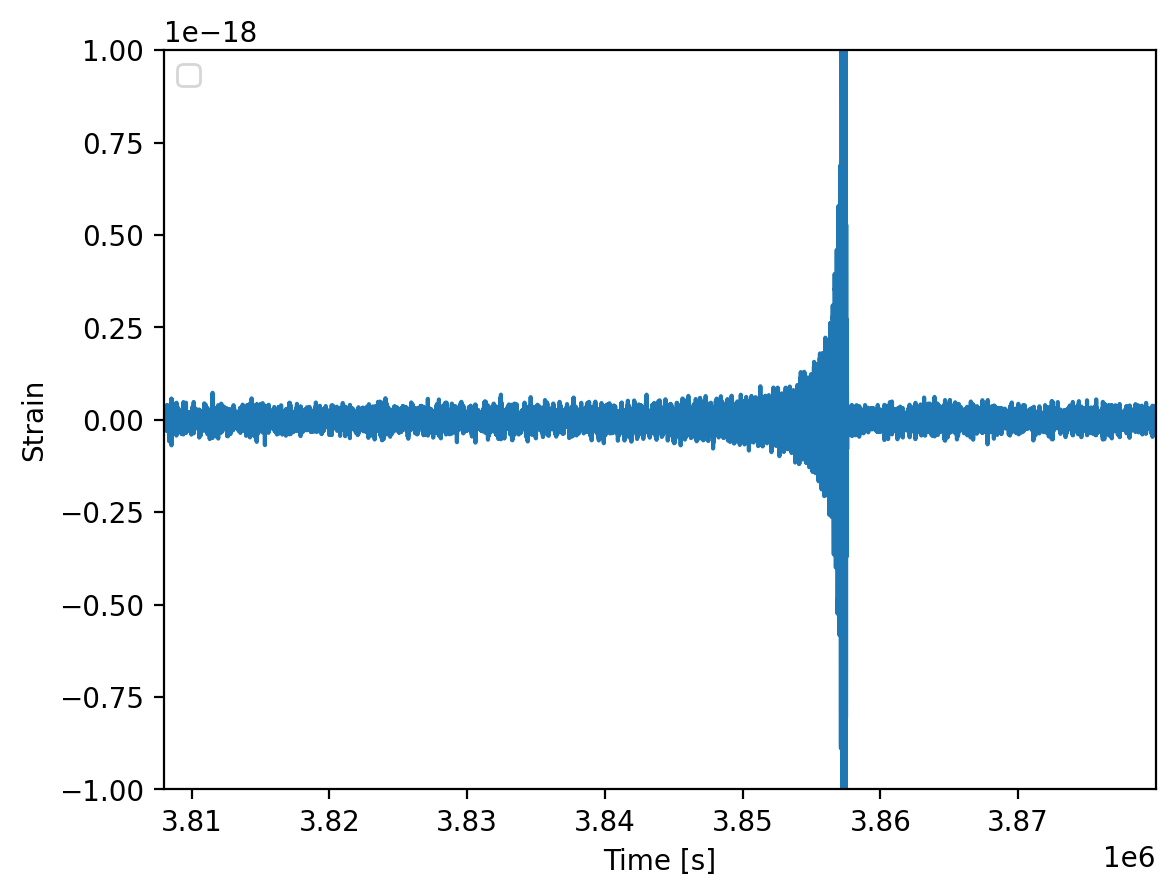

In [6]:
plot_lower = 10000
plot_upper = 1000
plt.plot(t_array, data_t[0])
plt.xlim(cutoff_time, max_time)
plt.ylim(-1e-18, 1e-18)
plt.xlabel("Time [s]")
plt.ylabel("Strain")
plt.legend(loc='upper left')
plt.show()

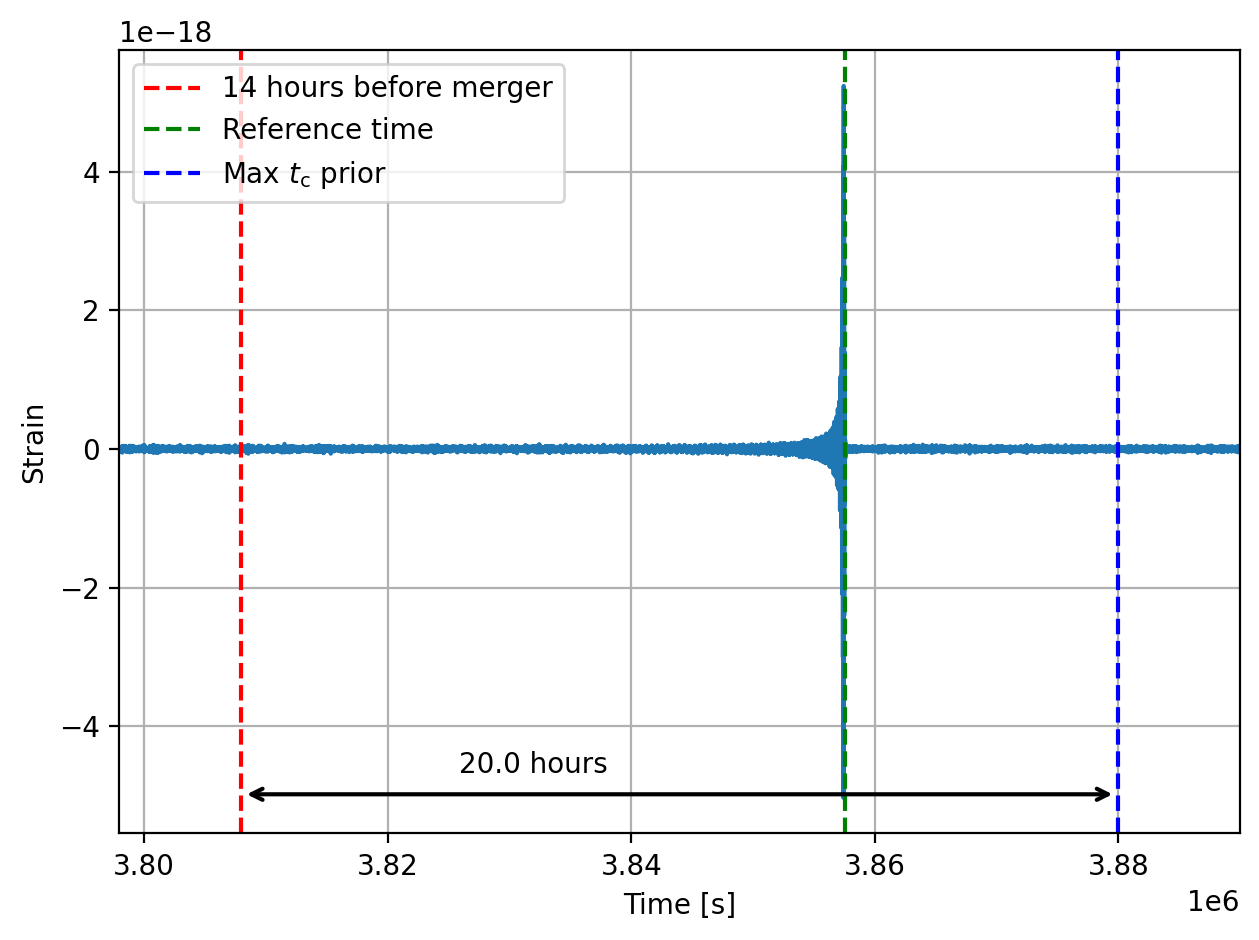

In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

# Your original plotting code
plot_lower = 10000
plot_upper = 10000

plt.plot(t_array, data_t[0])
plt.xlim(cutoff_time - plot_lower, plot_upper + max_time)
plt.xlabel("Time [s]")
plt.ylabel("Strain")

# Vertical reference lines
plt.axvline(cutoff_time, color='r', linestyle='--', label=f"{hours_before_merger} hours before merger")
plt.axvline(t_ref-800, color='g', linestyle='--', label="Reference time")
plt.axvline(max_time, color='b', linestyle='--', label="Max $t_{\\mathrm{c}}$ prior")

# Add horizontal double-headed arrow to show distance
y_pos = plt.ylim()[0] + 0.05 * (plt.ylim()[1] - plt.ylim()[0])  # Just above the bottom
plt.annotate(
    '',
    xy=(cutoff_time, y_pos),
    xytext=(max_time, y_pos),
    arrowprops=dict(arrowstyle='<->', color='black', lw=1.5)
)

# Add a label for the distance
midpoint = (cutoff_time * 2 + max_time) / 3
plt.text(
    midpoint,
    y_pos + 0.02 * (plt.ylim()[1] - plt.ylim()[0]),  # Slightly above the arrow
    f"{(max_time - cutoff_time)/3600:.1f} hours",
    ha='center',
    va='bottom',
    fontsize=10,
    color='black'
)

# Final plot settings
plt.legend(loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.show()


In [8]:
analysis = TimeFreqLikelihood(data_t=data_t, wave_gen=wave_gen, nperseg=nperseg)
analysis.pre_merger(time_before_merger=time_before_merger, t_ref=t_ref, t_array=t_array)
analysis.get_stft_of_data()
print("Best likelihood (true parameters)= ", analysis.calculate_time_frequency_likelihood(*parameters, waveform_kwargs=waveform_kwargs))

Best likelihood (true parameters)=  -358.70722443600306


# MCMC

In [ ]:
# MCMC parameters
nwalkers = 24
ntemps = 4
ndims = 11
nleaves_max = 1
nsteps = 1500
perturb_frac = 0.02

param_labels = [
    r"$M_T \, [\mathrm{M_\odot}]$",
    r"$q$",
    r"$a_1$",
    r"$a_2$",
    r"$d_L \, [\mathrm{Gpc}]$",
    r"$\phi_{\mathrm{ref}}$",
    r"$\cos(\iota)$",
    r"$\lambda$",
    r"$\sin(\beta)$",
    r"$\psi$",
    r"$t_{\mathrm{c}} \, [\mathrm{s}]$"
]

In [33]:
def likelihood(x, freqs, TimeFreqLikelihood_object):
    all_parameters = np.zeros(12)
    mT = x[0]
    q = x[1]
    all_parameters[0] = mT / (1 + q)
    all_parameters[1] = mT * q / (1 + q)
    all_parameters[2] = x[2]
    all_parameters[3] = x[3]
    all_parameters[4] = x[4] * PC_SI * 1e9
    all_parameters[5] = x[5]
    all_parameters[6] = f_ref
    all_parameters[7] = np.arccos(x[6])
    all_parameters[8] = x[7]
    all_parameters[9] = np.arcsin(x[8])
    all_parameters[10] = x[9]
    all_parameters[11] = x[10]

    ll = TimeFreqLikelihood_object.calculate_time_frequency_likelihood(
        *all_parameters,
        waveform_kwargs=dict(
        length=1024, 
        direct=False,
        fill=True,
        squeeze=False,
        freqs=freqs,
        modes=modes
        )
    )
    return ll

In [34]:
priors = {"mbh": ProbDistContainer({
        0 : uniform_dist(1e5, 1e6),                  # mT = m1 + m2
        1 : uniform_dist(0.01, 0.99),                # q = m2/m1
        2 : uniform_dist(-1, +1),                    # a1
        3 : uniform_dist(-1, +1),                    # a2
        4 : uniform_dist(1, 50),                     # dist in Mpc
        5 : uniform_dist(0, 2*np.pi),                # phi_ref
        6 : uniform_dist(-1, 1),                     # cos(inc)
        7 : uniform_dist(0.0, 2 * np.pi),            # lam
        8 : uniform_dist(-1.0, 1.0),                 # sin(beta)
        9 : uniform_dist(0.0, np.pi),                # psi
        10: uniform_dist(cutoff_time, max_time),     # t_ref
    })}

periodic = {"mbh": {5: 2 * np.pi,                # phi_ref
                    7: 2 * np.pi,                # lam
                    9: np.pi  }}                 # psi

In [35]:
sampler = EnsembleSampler(
    nwalkers,
    ndims,
    likelihood,
    priors,
    args=(f_array, analysis),
    branch_names=["mbh"],
    tempering_kwargs=dict(ntemps = ntemps),
    nleaves_max=dict(mbh = nleaves_max),
    periodic=periodic
)

# Get Results from Differential Evolution

In [36]:
def DE_to_MCMC_params(found_parameters_DE, cutoff_time):
    mT, q, a1, a2, dist_Gpc, phi_ref, cos_inc, lam, sin_beta, psi, t_ref_01 = found_parameters_DE
    mT_exp = np.exp(mT)
    dist_Mpc = dist_Gpc 
    phi_ref = phi_ref % (2*np.pi)
    t_ref = t_ref_01 * (60*60*24) + cutoff_time
    return np.array([mT_exp, q, a1, a2, dist_Mpc, phi_ref, cos_inc, lam, sin_beta, psi, t_ref])

x0 = load_de_results(filepath='differential_evolution/differential_evolution_results/tf_run_20250915_094350.npz')
found_parameters_DE = DE_to_MCMC_params(x0['found_parameters'], cutoff_time=cutoff_time)
print("Found parameters from DE: ", found_parameters_DE)
print("SNR of DE result = ", x0['found_snr'])

Found parameters from DE:  [4.27931330e+05 6.77568542e-01 8.20058806e-01 2.62087167e-01
 9.93483702e+00 4.12772794e+00 9.71511293e-01 8.43205896e-01
 3.90984925e-01 2.12432232e+00 3.85782534e+06]
SNR of DE result =  0.4604640876439373


In [37]:
"""for label, value in zip(param_labels, found_parameters_DE):
    idx = param_labels.index(label)
    print(f"{label:<32} : {value:>15.6f}    (true: {injection_parameters[idx]:>15.6f})")"""

'for label, value in zip(param_labels, found_parameters_DE):\n    idx = param_labels.index(label)\n    print(f"{label:<32} : {value:>15.6f}    (true: {injection_parameters[idx]:>15.6f})")'

# Generate starting points for mcmc

In [38]:
injection_parameters = np.array([m1+m2, m2/m1, a1, a2, dist / (PC_SI * 1e9), phi_ref, np.cos(inc), lam, np.sin(beta), psi, t_ref])
starting_points = np.zeros(shape=[ntemps, nwalkers, nleaves_max, found_parameters_DE.shape[0]])

# Perturb the injection parameters to create starting points for the walkers
perturb_frac = 0.02

non_periodic_params = [0, 1, 2, 3, 4, 6, 7, 8, 10]  # indices of non-periodic parameters

# For non-periodic parameters, draw from a truncated normal distribution around the injection parameters
for i in non_periodic_params:
    low, high = priors["mbh"].priors[i][1].min_val, priors["mbh"].priors[i][1].max_val
    mu = found_parameters_DE[i]
    sigma = perturb_frac * (high - low)
    a, b = (low - mu) / sigma, (high - mu) / sigma
    starting_points[:, :, :, i] = truncnorm.rvs(a, b, loc=mu, scale=sigma, size=(ntemps, nwalkers, nleaves_max))

# For periodic parameters, draw from a normal distribution around the injection parameters and then wrap around the period
for i, period in periodic["mbh"].items():
    sigma = perturb_frac * period
    perturbed = found_parameters_DE[i] + sigma * np.random.randn(ntemps, nwalkers, nleaves_max)
    starting_points[:, :, :, i] = np.mod(perturbed, period)

starting_state = State({"mbh": starting_points})

Mean of parameter 7 is 1.0471975511965976
Sigma of parameter 7 is 0.12566370614359174


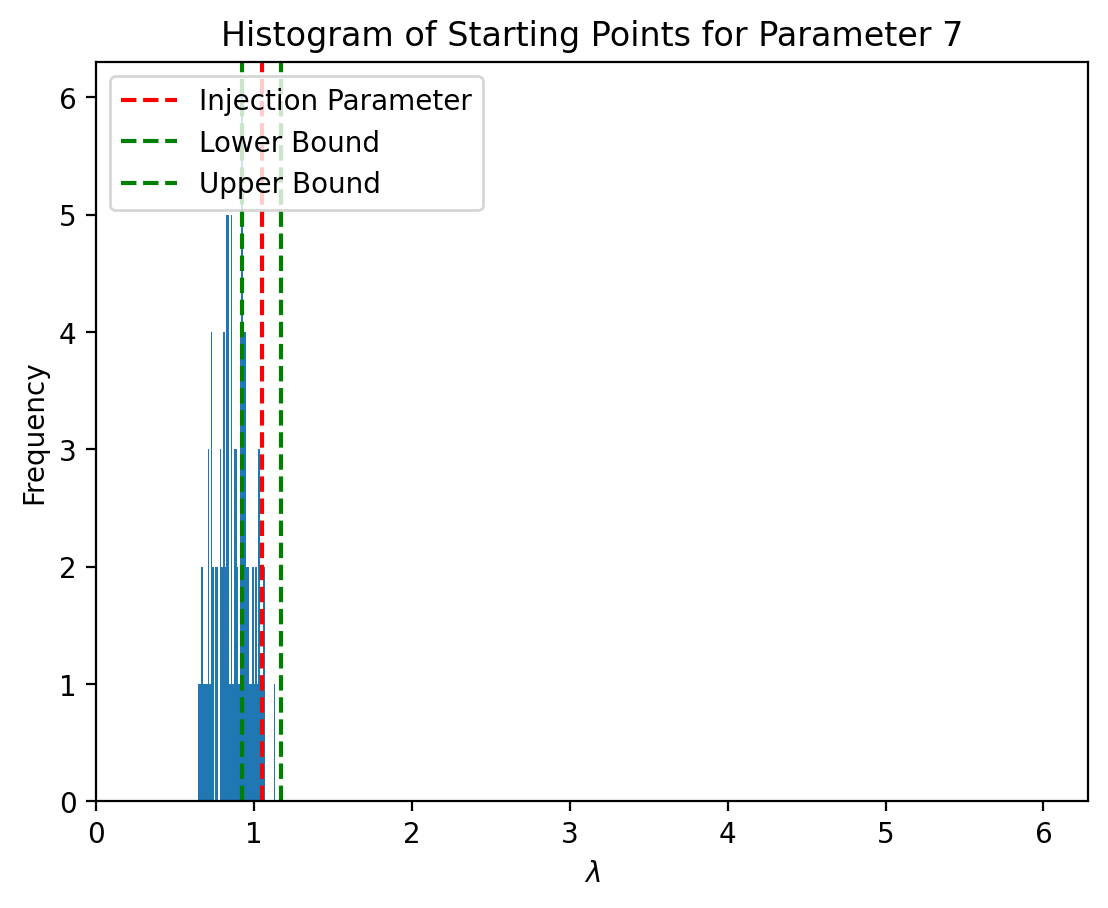

In [39]:
# Plot the histogram of the starting points
index_for_histogram = 7

size_of_prior = priors["mbh"].priors[index_for_histogram][1].max_val - priors["mbh"].priors[index_for_histogram][1].min_val
print("Mean of parameter", index_for_histogram, "is", injection_parameters[index_for_histogram])
print("Sigma of parameter", index_for_histogram, "is", perturb_frac * size_of_prior)

plt.hist(starting_points[:, :, :, index_for_histogram].flatten(), bins=50)
plt.axvline(injection_parameters[index_for_histogram], color='r', linestyle='--', label='Injection Parameter')
plt.axvline(injection_parameters[index_for_histogram] - perturb_frac * size_of_prior, color='g', linestyle='--', label='Lower Bound')
plt.axvline(injection_parameters[index_for_histogram] + perturb_frac * size_of_prior, color='g', linestyle='--', label='Upper Bound')
plt.title(f'Histogram of Starting Points for Parameter {index_for_histogram}')
plt.xlabel(param_labels[index_for_histogram])
plt.xlim(priors["mbh"].priors[index_for_histogram][1].min_val, priors["mbh"].priors[index_for_histogram][1].max_val)
plt.ylabel('Frequency')
plt.legend(loc='upper left')
plt.show()

In [40]:
sampler.run_mcmc(starting_state, nsteps=nsteps, progress=True)

100%|██████████| 100/100 [1:25:39<00:00, 51.39s/it]  


# Plotting

In [41]:
injection_parameters

array([4.50000000e+05, 5.00000000e-01, 7.53000000e-01, 6.21000000e-01,
       1.00000000e+01, 0.00000000e+00, 9.75016726e-01, 1.04719755e+00,
       3.42020143e-01, 0.00000000e+00, 3.85836872e+06])

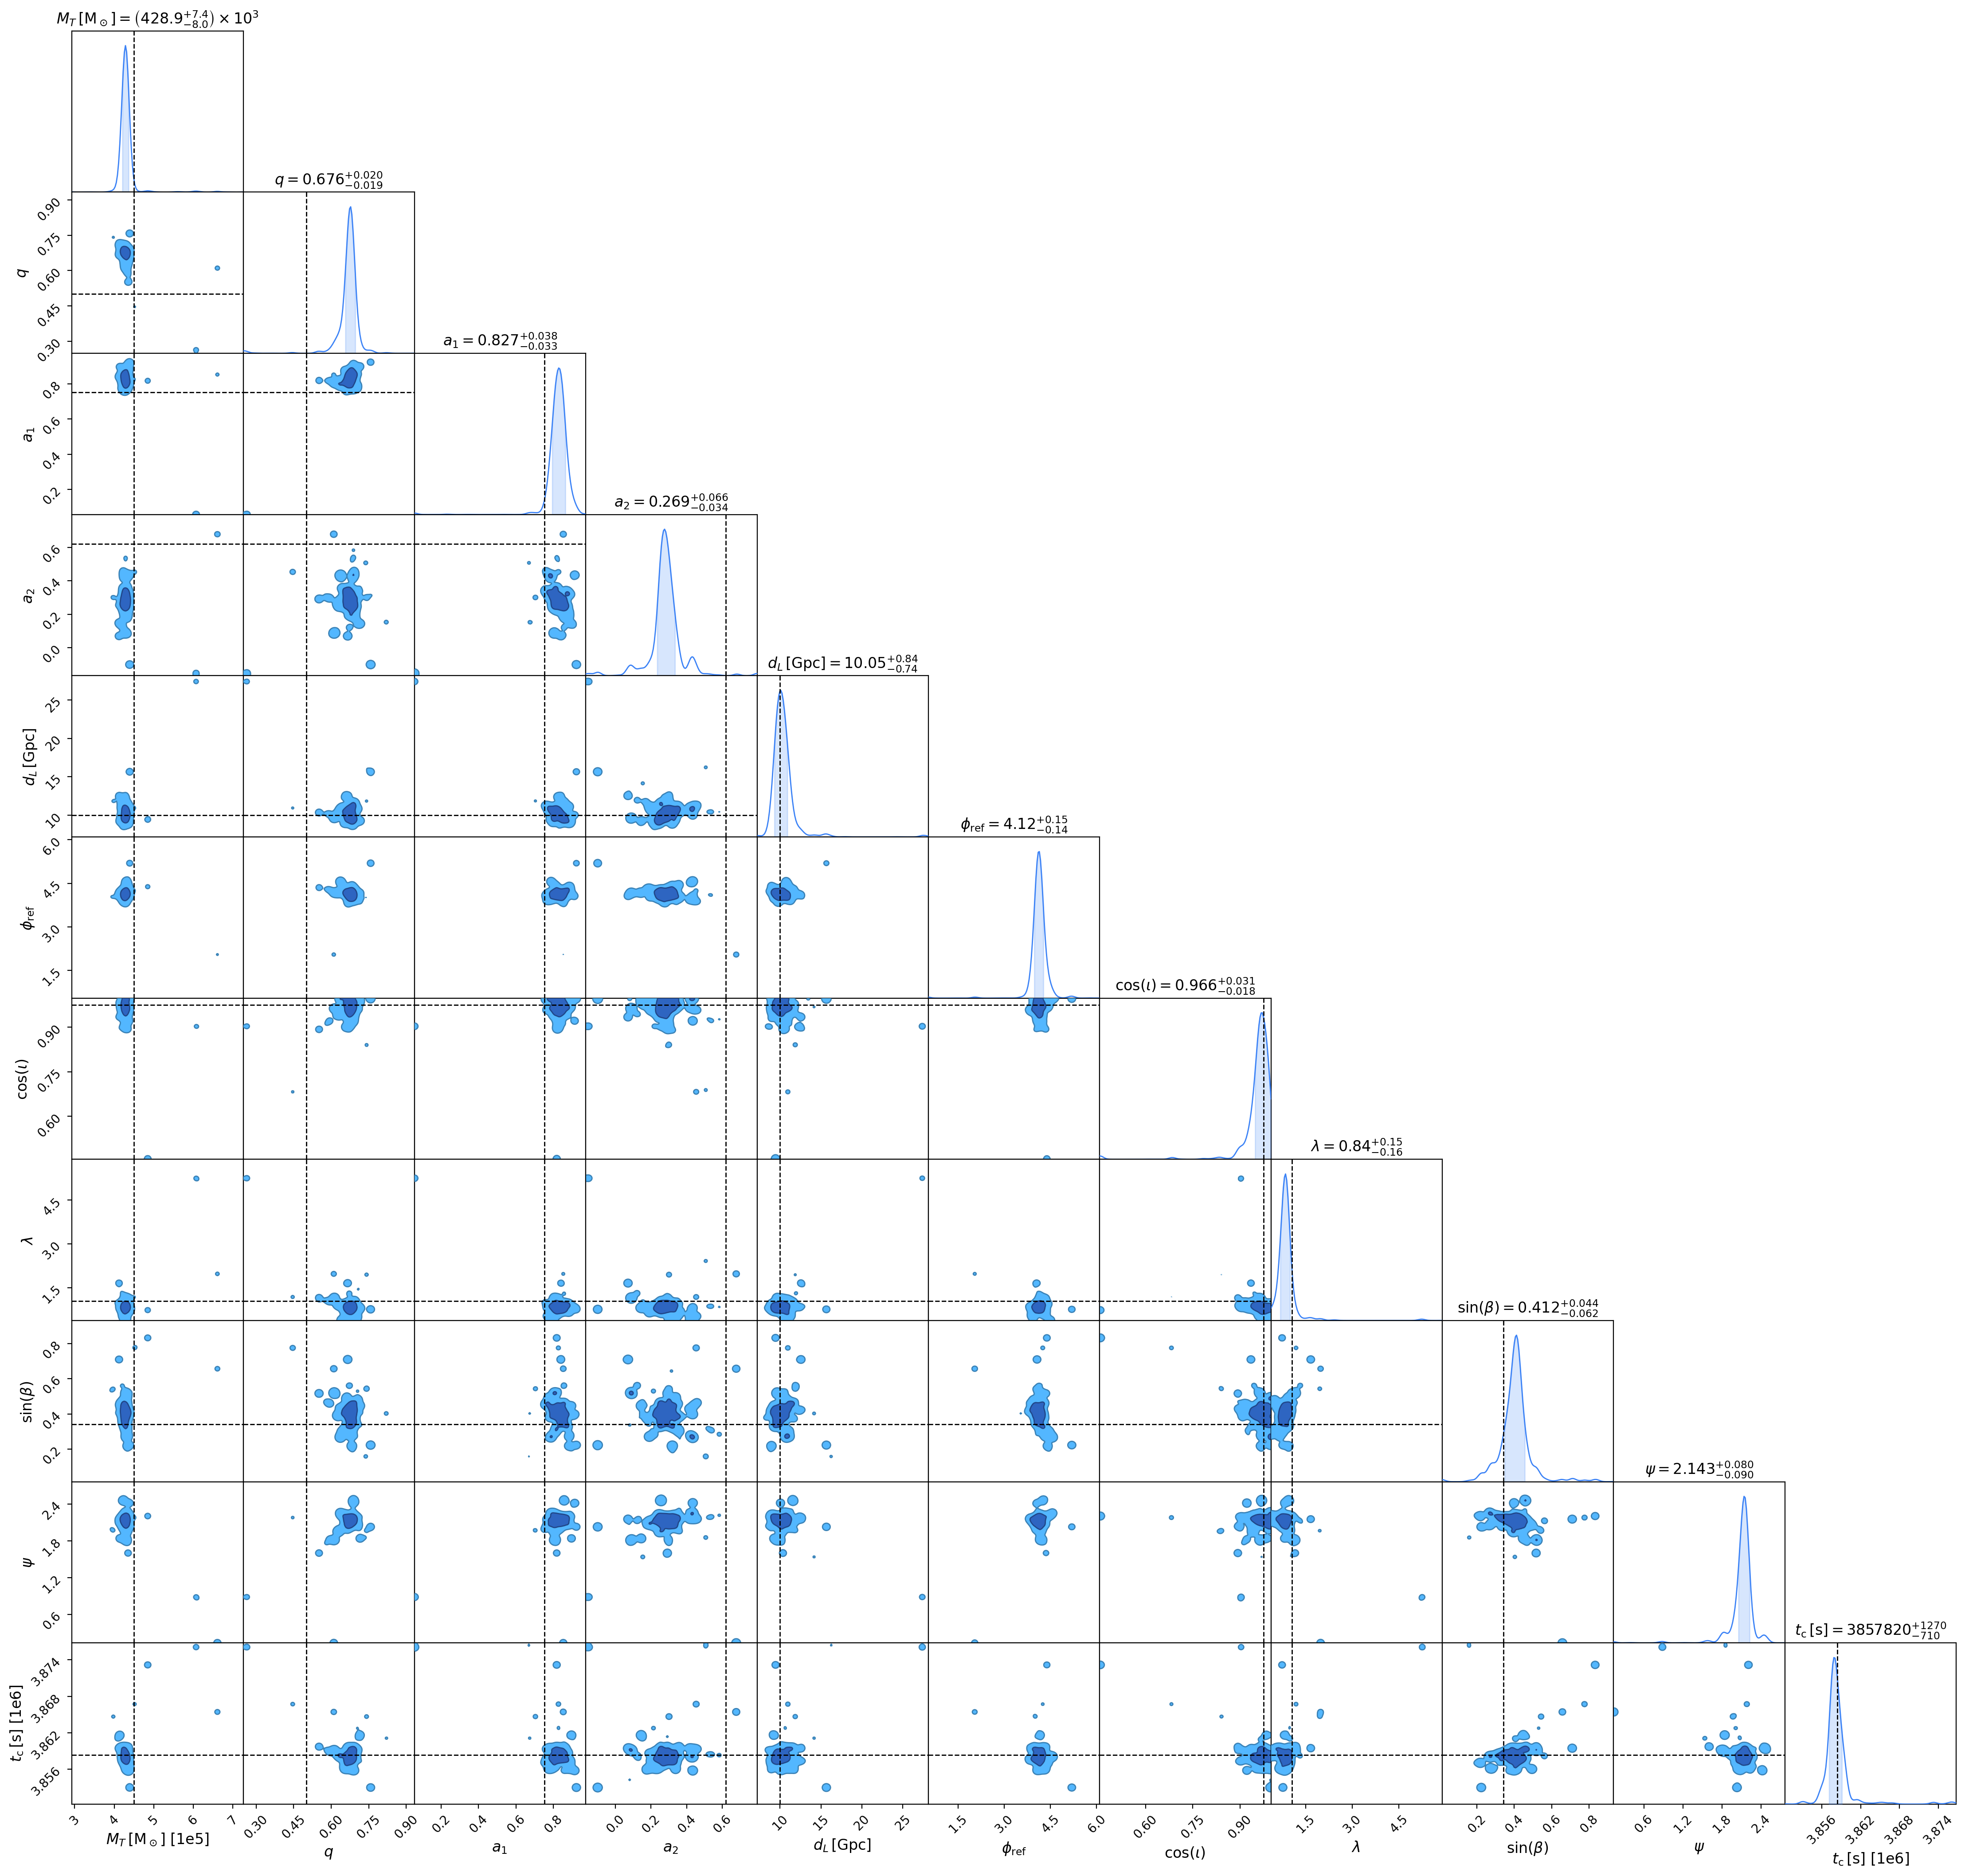

In [43]:
from chainconsumer import Chain, ChainConsumer, make_sample, Truth
import pandas as pd

mcmc_results = sampler.get_chain()["mbh"]

samples = mcmc_results[:, 0].reshape(-1, 11)
df = pd.DataFrame(samples, columns=param_labels)

#burn_in_2 = 5000                           # Remove burn-in samples if needed
#df_post_burnin = df.iloc[burn_in_2:]

injection_parameters = np.array([m1+m2, m2/m1, a1, a2, dist / (PC_SI * 1e9), phi_ref, np.cos(inc), lam, np.sin(beta), psi, t_ref])
c = ChainConsumer() 
c.add_chain(Chain(samples=df, name="MCMC Results"))
c.add_truth(Truth(location = dict(zip(param_labels[:11], injection_parameters[:11]))))
fig = c.plotter.plot()

In [ ]:
#df.to_pickle("first_working_mcmc_1500.pkl")
#df = pd.read_pickle("first_working_mcmc_1500.pkl")

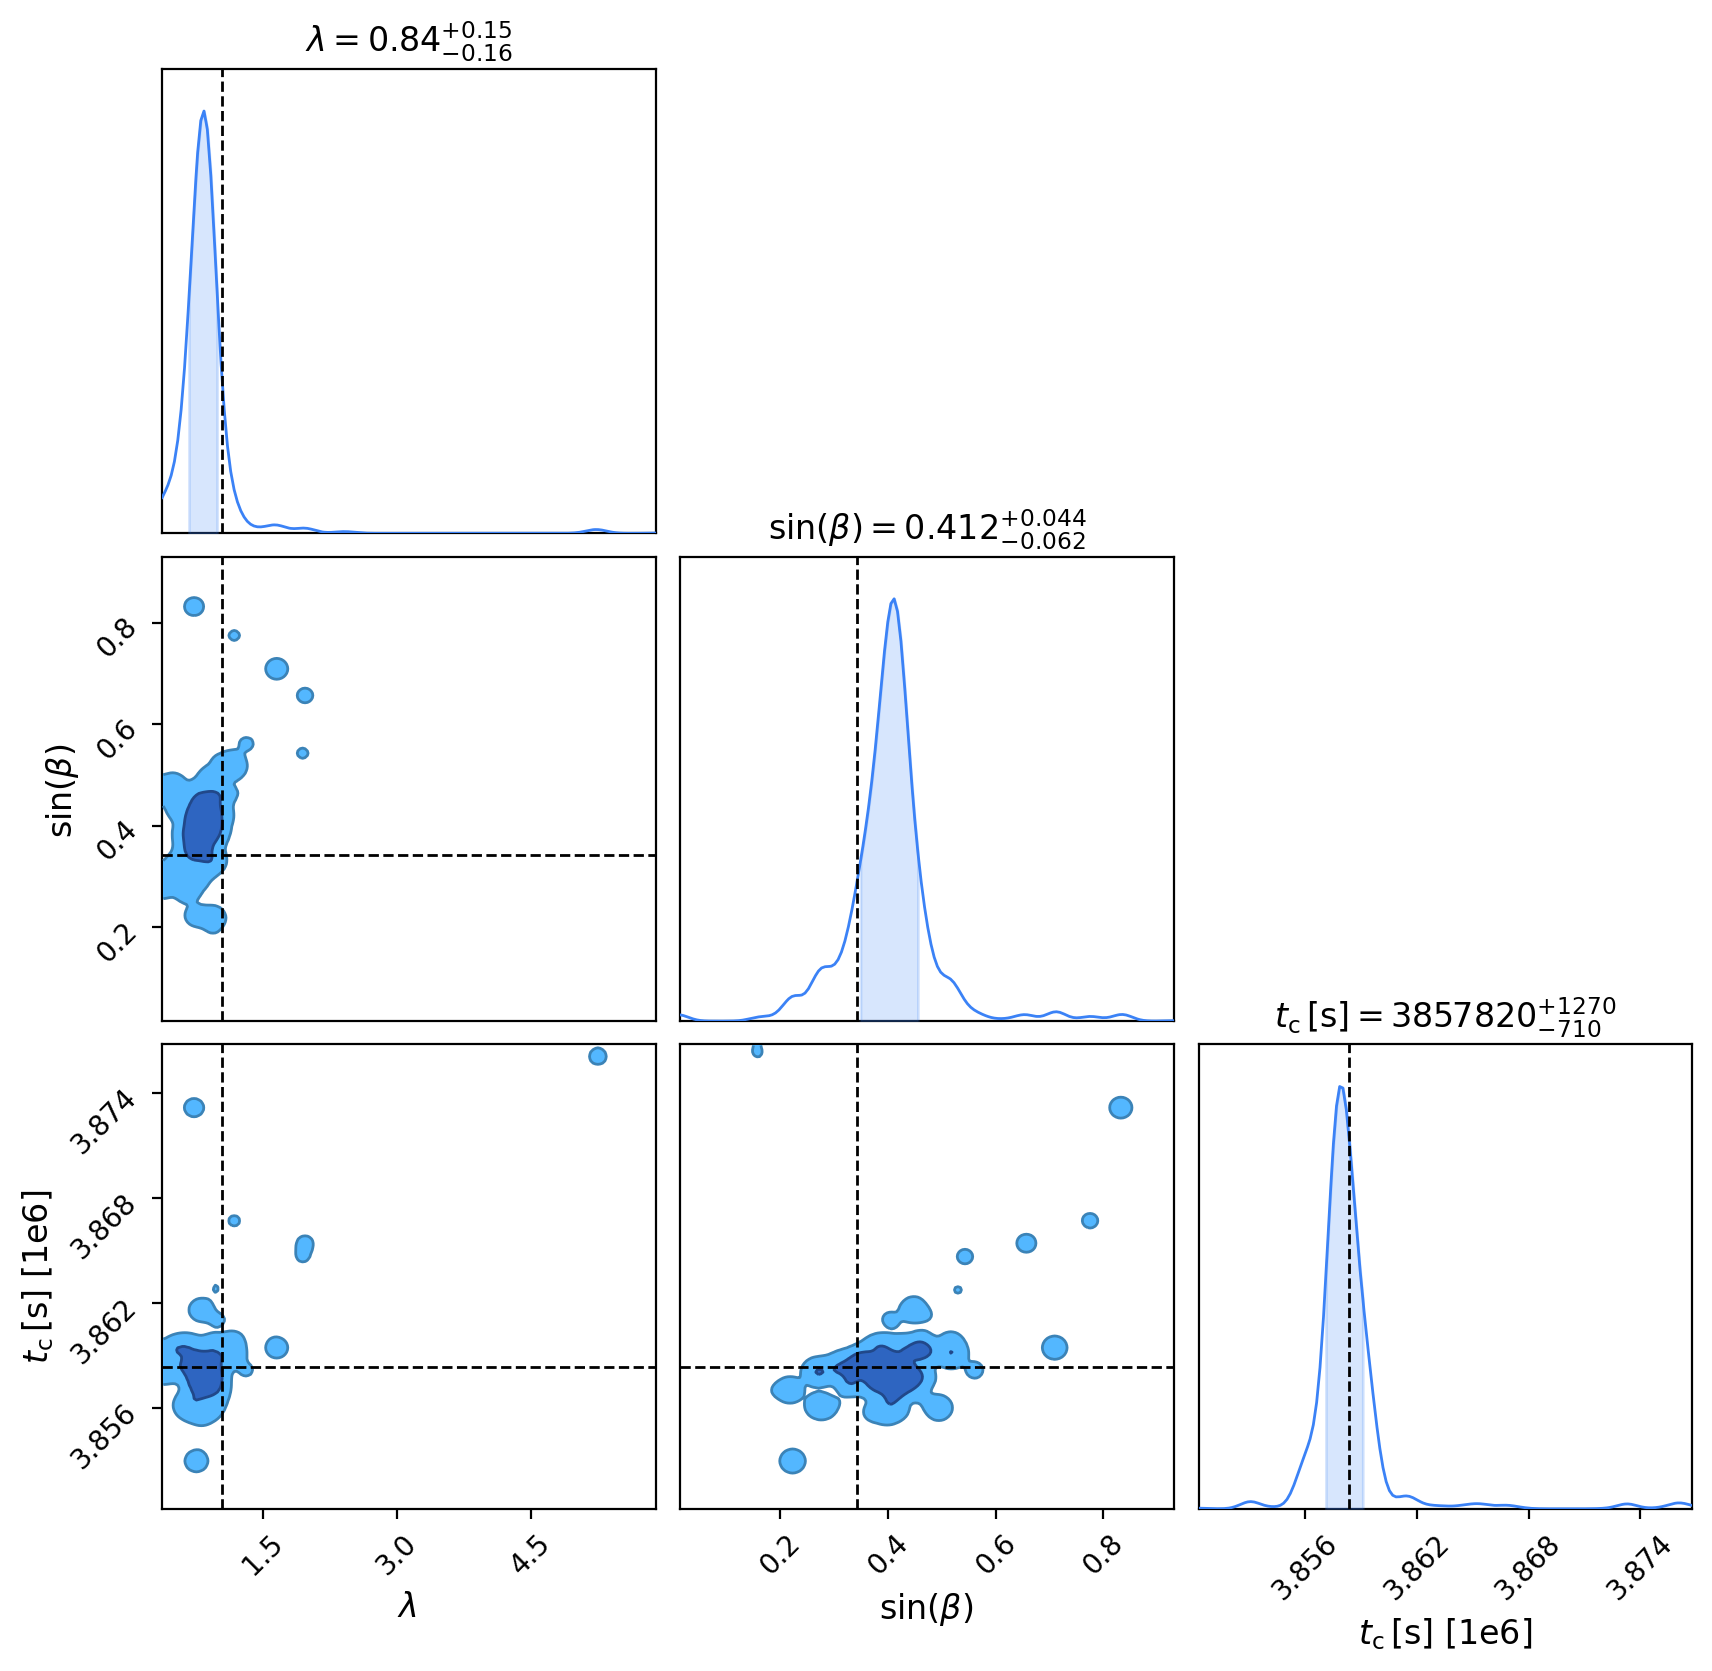

In [46]:
from chainconsumer import Chain, ChainConsumer, make_sample, Truth
import pandas as pd

new_df = df[["$\\lambda$", "$\\sin(\\beta)$", "$t_{\\mathrm{c}} \\, [\\mathrm{s}]$"]]

new_injection_parameters = np.array([lam, np.sin(beta), t_ref])
new_c = ChainConsumer() 
new_c.add_chain(Chain(samples=new_df, name="MCMC Results"))
new_c.add_truth(Truth(location={param_labels[7]: new_injection_parameters[0],
                                param_labels[8]: new_injection_parameters[1],
                                param_labels[10]: new_injection_parameters[2]}))
fig = new_c.plotter.plot()

# Burn in

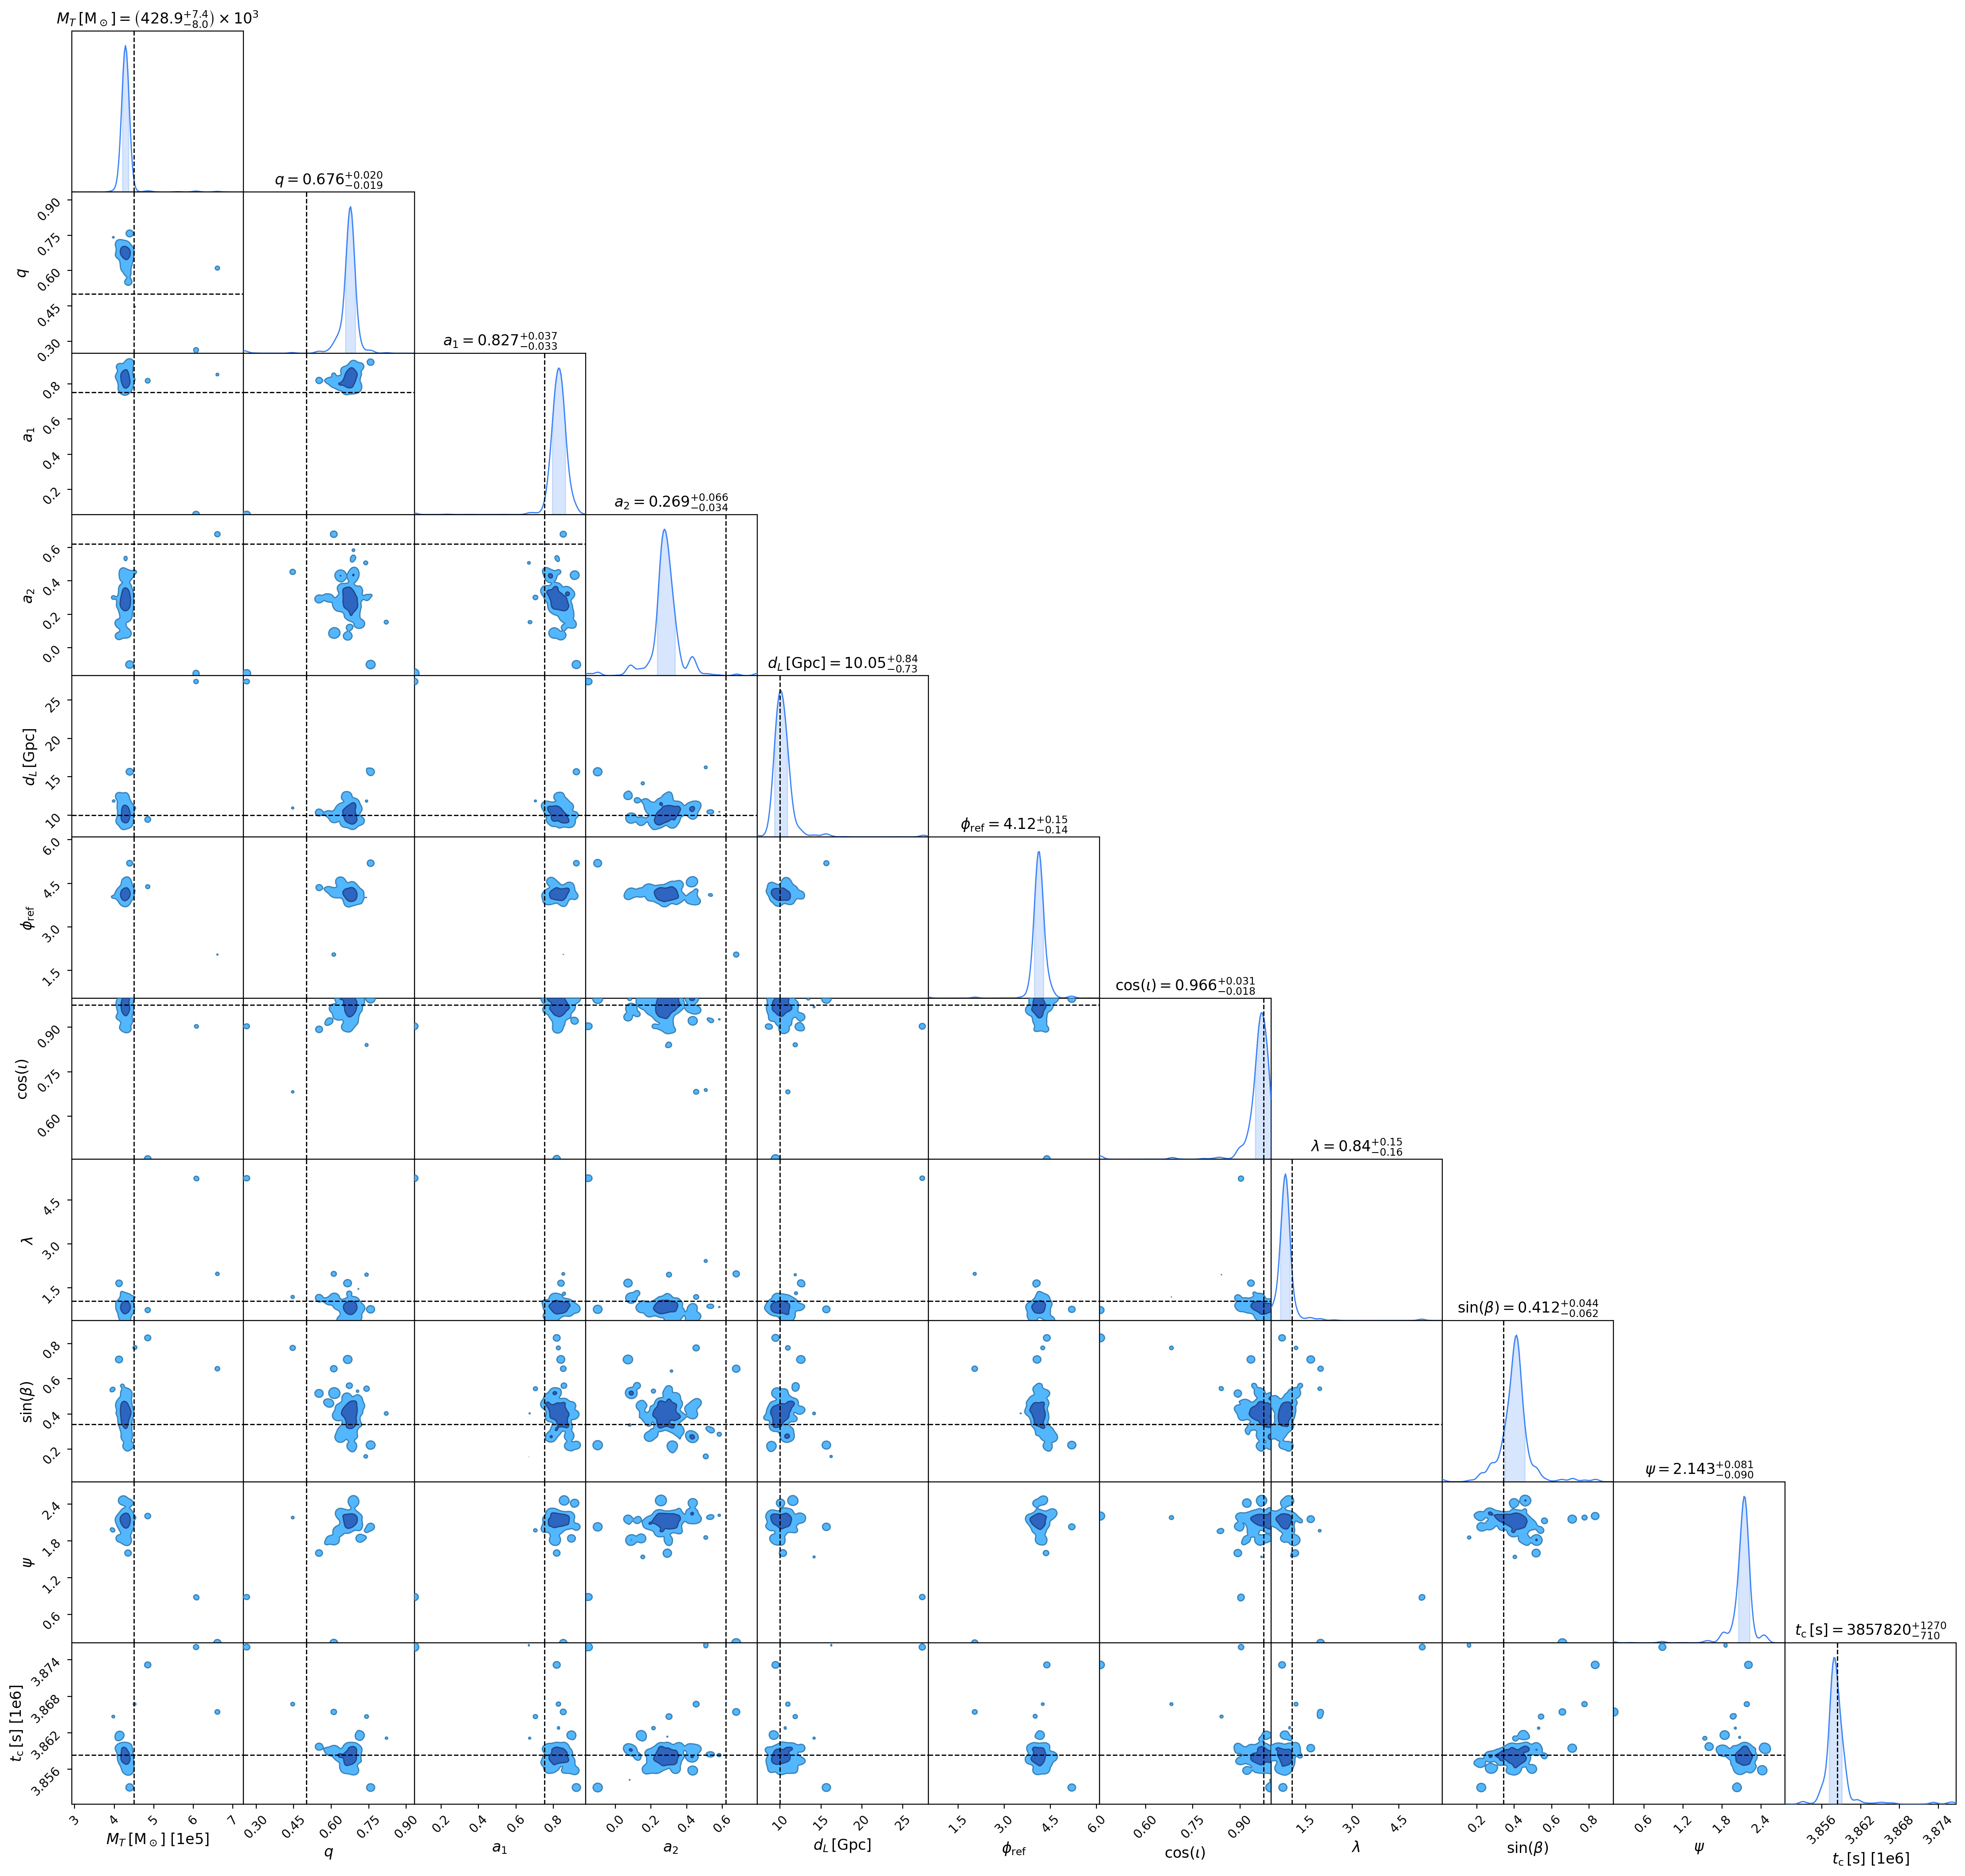

In [49]:
burn_in = 30
df_burnin = df.iloc[burn_in:]

c_burn_in = ChainConsumer() 
c_burn_in.add_chain(Chain(samples=df_burnin, name="MCMC Results"))
c_burn_in.add_truth(Truth(location = dict(zip(param_labels[:11], injection_parameters[:11]))))
fig_burn_in = c_burn_in.plotter.plot()

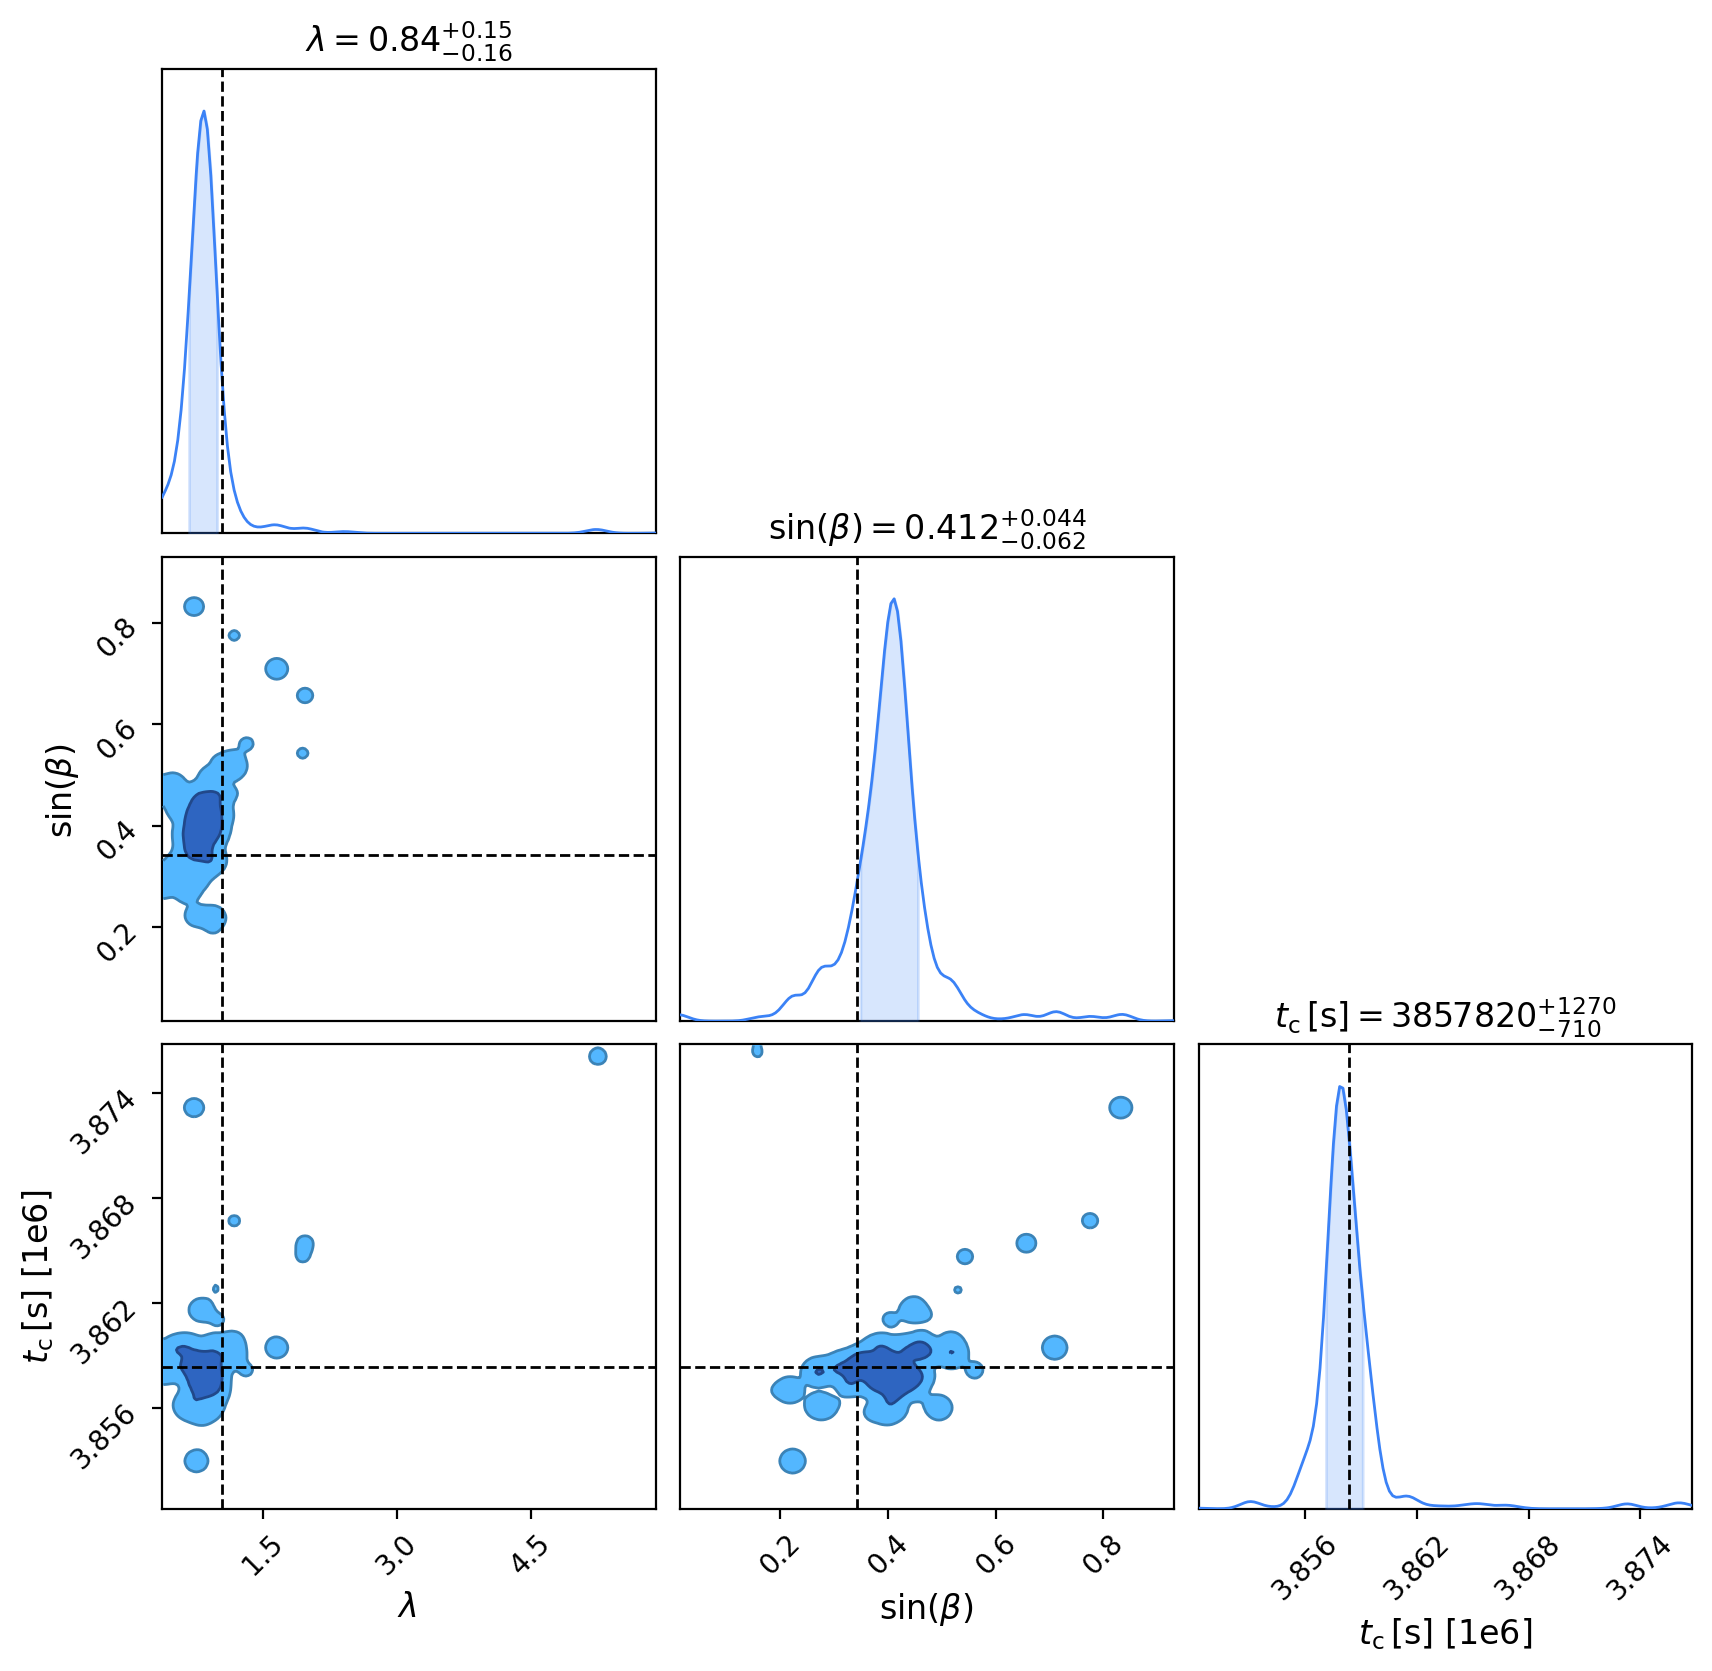

In [50]:
df_burnin_lam_beta_tc = df_burnin[["$\\lambda$", "$\\sin(\\beta)$", "$t_{\\mathrm{c}} \\, [\\mathrm{s}]$"]]
new_c_lam_beta_t = ChainConsumer() 
new_c_lam_beta_t.add_chain(Chain(samples=df_burnin_lam_beta_tc, name="MCMC Results"))
new_c_lam_beta_t.add_truth(Truth(location = dict(zip(param_labels[:11], injection_parameters[:11]))))
fig = new_c_lam_beta_t.plotter.plot()

Text(0.5, 0, 'Step')

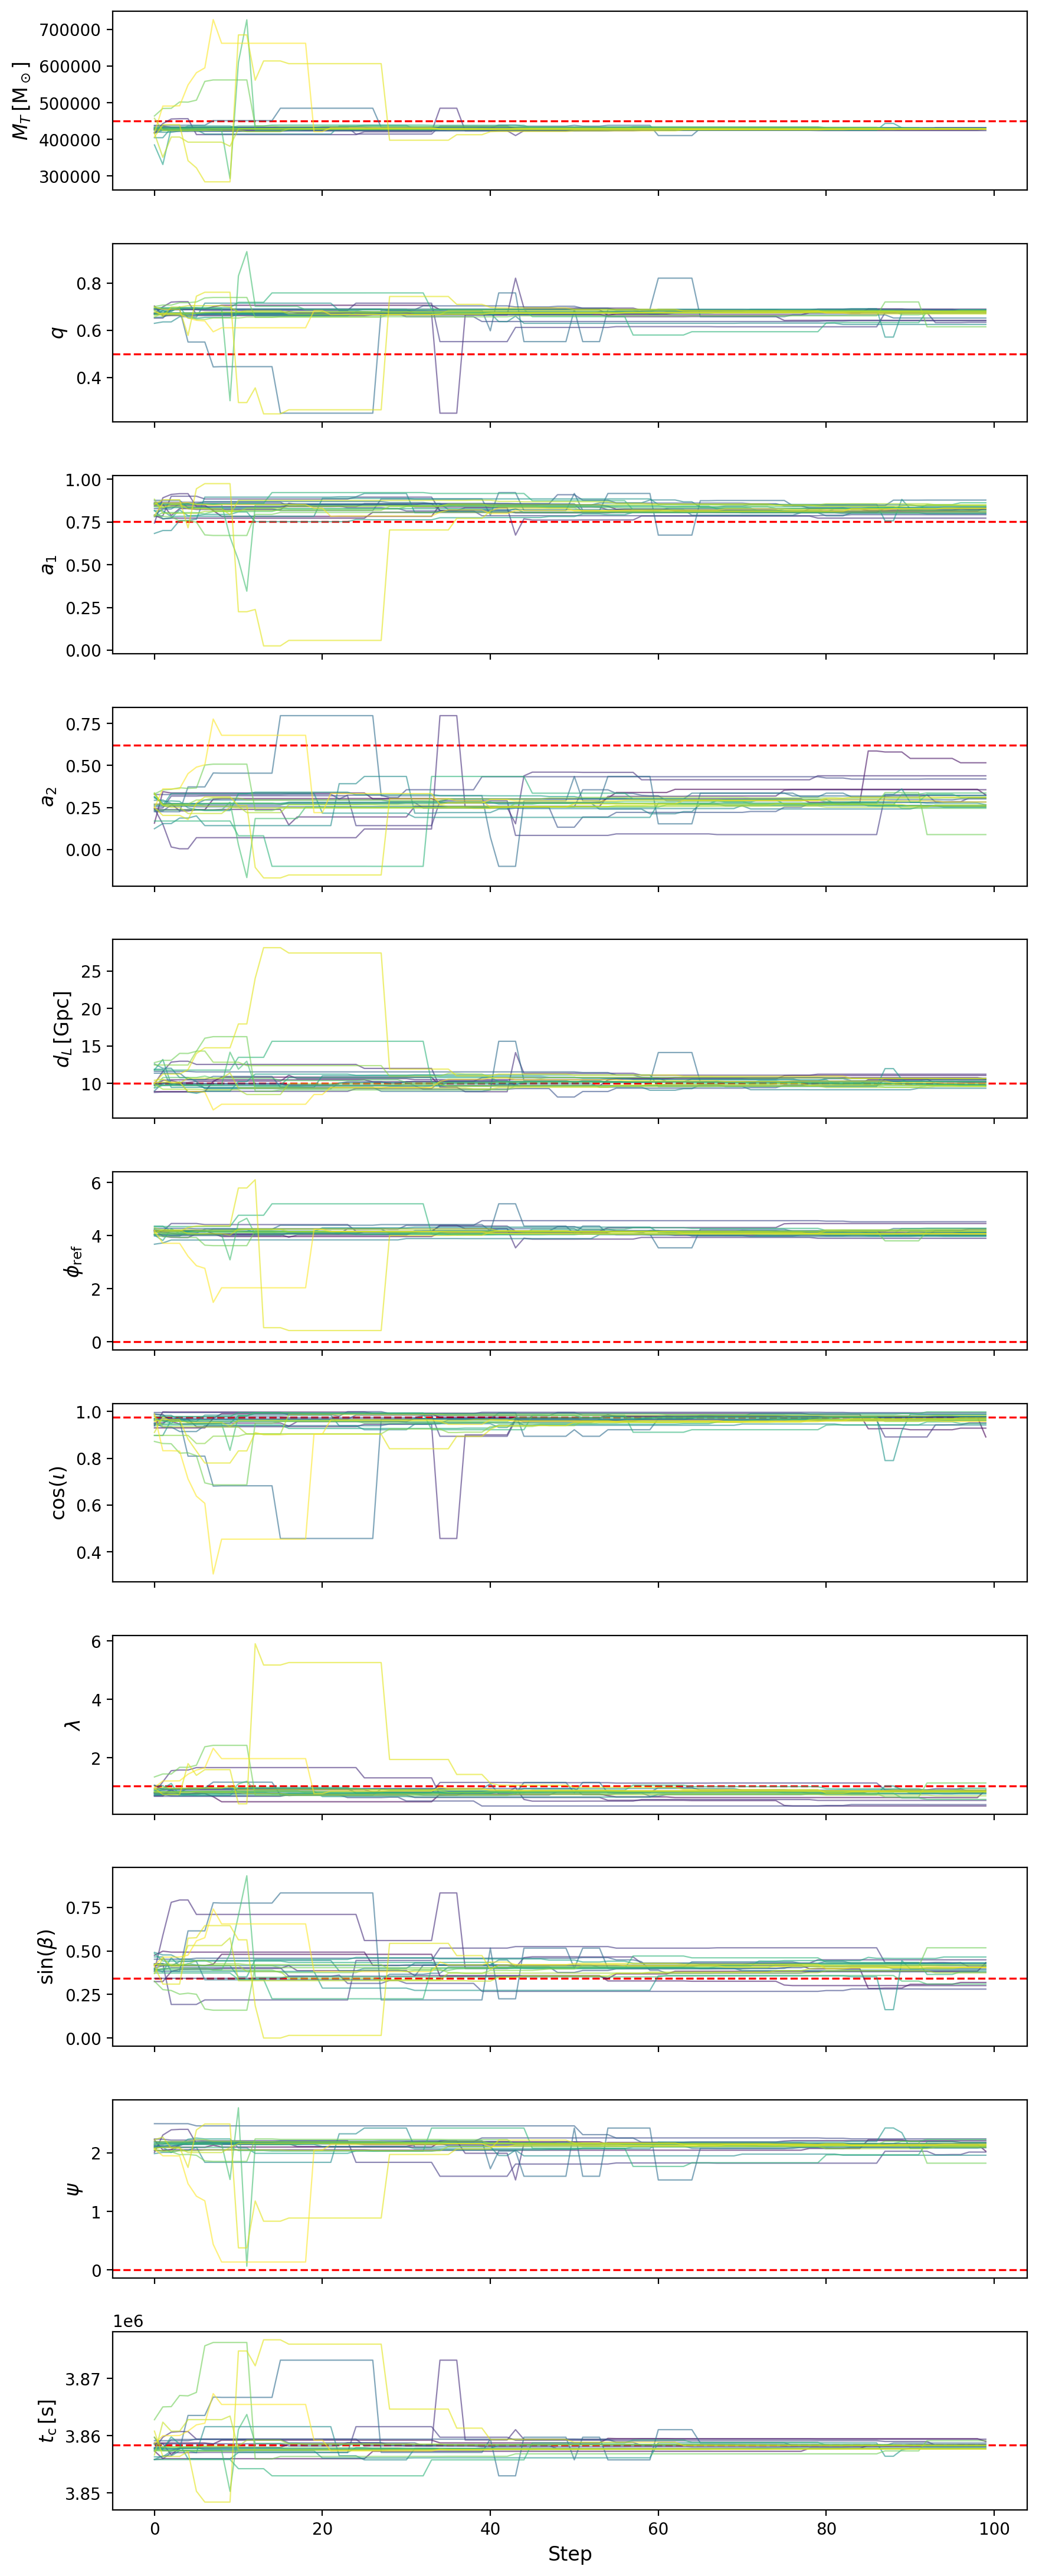

In [52]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

plotting_walkers_range = nwalkers
colors = cm.viridis(np.linspace(0, 1, plotting_walkers_range))

fig, ax = plt.subplots(ndims, 1, sharex=True, figsize=(10, 2.5 * ndims))
fig.subplots_adjust(hspace=0.3)


for i in range(ndims):
    ax[i].axhline(injection_parameters[i], color='red', linestyle='--', linewidth=1.2, label="True value")
    for walk in range(plotting_walkers_range):
        ax[i].plot(mcmc_results[:, 0, walk, :, i].flatten(), color=colors[walk], alpha=0.6, linewidth=0.8)
    #ax[i].axhline(starting_points[0, walk, :, i], color='blue', linestyle='--', linewidth=1.2, label="Starting point of the last walker")

    ax[i].set_ylabel(param_labels[i], fontsize=12)
    #ax[i].legend(loc='upper right', fontsize=10)

ax[-1].set_xlabel("Step", fontsize=12)


Text(0, 0.5, 'Log-likelihood')

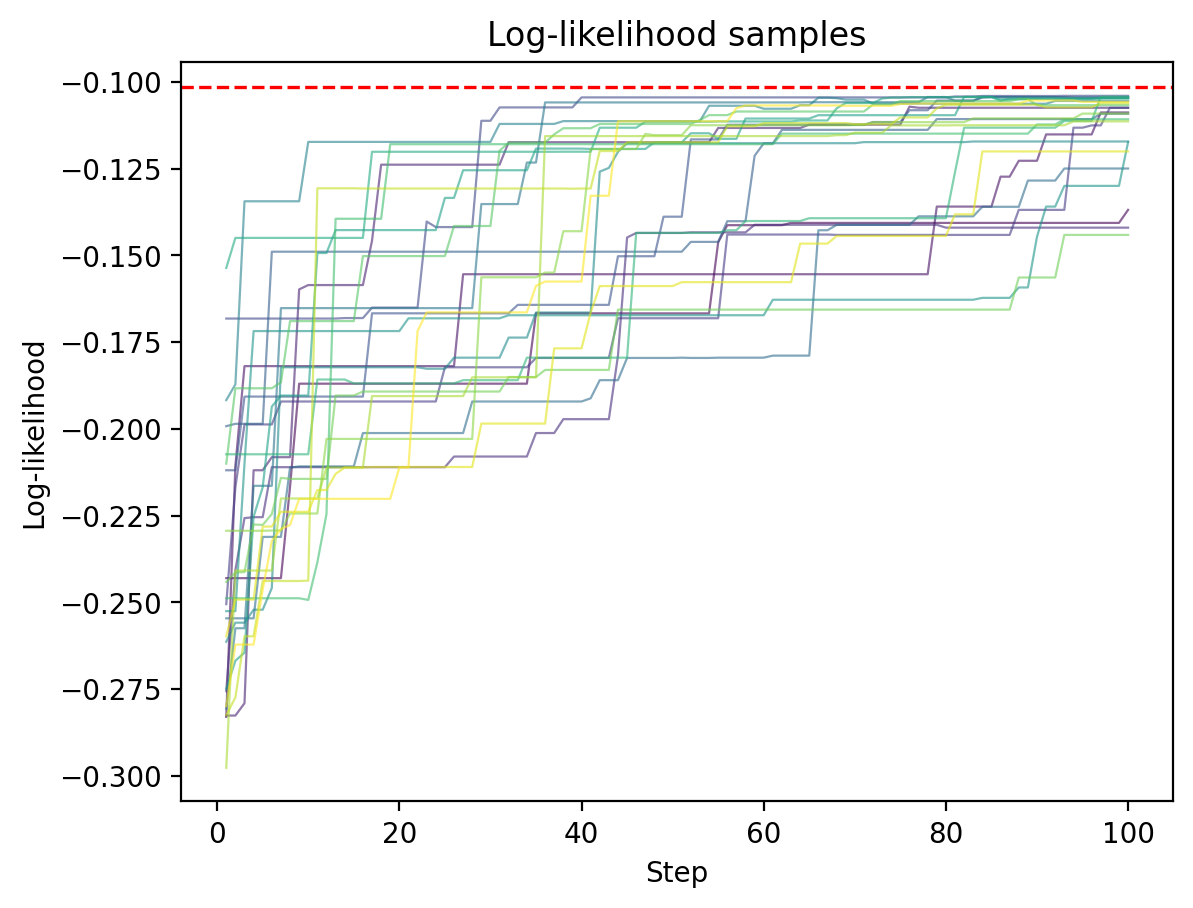

In [53]:
log_like_samples = sampler.get_log_like() 

for i in range(nwalkers):
    plt.plot(np.arange(1, log_like_samples.shape[0]+1), log_like_samples[:,0,i]/analysis.dt, label=f"Walker {i+1}", color=colors[i], alpha=0.6, linewidth=0.8)

plt.axhline(analysis.calculate_time_frequency_likelihood(*parameters, waveform_kwargs=waveform_kwargs) / analysis.dt , 
            color='red', linestyle='--', linewidth=1.2, label="Likelihood of Injection Parameters")

plt.title("Log-likelihood samples")
plt.xlabel("Step")
plt.ylabel("Log-likelihood")
#plt.xticks(nsteps)
#plt.ylim(-1000, 0)
#plt.legend()


In [ ]:
"""import os
os.system("say 'Computation is done!'")"""

In [7]:
from chainconsumer import Chain, ChainConsumer, make_sample, Truth
import pandas as pd
loaded_df = pd.read_pickle("first_working_mcmc_1500.pkl")

,"$M_T \, [\mathrm{M_\odot}]$",$q$,$a_1$,$a_2$,"$d_L \, [\mathrm{Gpc}]$",$\phi_{\mathrm{ref}}$,$\cos(\iota)$,$\lambda$,$\sin(\beta)$,$\psi$,"$t_{\mathrm{c}} \, [\mathrm{s}]$"
0,442323.870104,0.637785,0.648171,0.797347,9.654534,6.269443,0.955932,1.446490,0.307511,0.510619,3.070722e+06
1,364030.382846,0.616928,0.551591,0.752541,10.907394,0.156978,0.964514,1.542467,0.208336,0.109449,3.067256e+06
2,435510.513644,0.650927,0.646195,0.808719,7.564220,0.201529,0.938420,1.132077,0.314298,0.404262,3.069218e+06
3,433941.478229,0.655999,0.650751,0.782465,9.484998,0.112473,0.983493,1.517557,0.367556,0.297186,3.068107e+06
4,435331.232088,0.623044,0.660371,0.798119,8.671451,0.073859,0.910204,1.003374,0.330658,0.424759,3.069682e+06
...,...,...,...,...,...,...,...,...,...,...,...
35995,432354.059000,0.638678,0.628504,0.962501,12.098863,5.629016,0.984685,0.940462,0.178983,1.975301,3.069688e+06
35996,431467.900349,0.653026,0.707248,0.899813,9.180892,4.193859,0.946561,0.913723,0.411697,2.331485,3.069753e+06
35997,430076.932000,0.659922,0.679393,0.721458,9.631794,0.717407,0.762072,0.925742,0.233504,0.407414,3.069417e+06
35998,431533.407241,0.642058,0.603390,0.874803,10.637369,0.153687,0.941784,0.987382,0.319410,0.236391,3.069444e+06


In [31]:
# Extract total mass (M_T) and mass ratio (q) and convert to individual masses
M_T = loaded_df.iloc[:, 0].to_numpy()
q = loaded_df.iloc[:, 1].to_numpy()

m1_individual = M_T / (1.0 + q)
m2_individual = M_T * q / (1.0 + q)

individual_masses = pd.DataFrame({
    param_labels[0]: m1_individual,
    param_labels[1]: m2_individual,
})

individual_masses.head()

,"$M_T \, [\mathrm{M_\odot}]$",$q$
0,270074.402784,172249.467320
1,225137.004638,138893.378208
2,263797.624812,171712.888832
3,262042.124744,171899.353485
4,268219.015334,167112.216753
